In [1]:
AUTHOR = "Swapnik Hazari"
CREATION_DATE = "2026-07-03"

class _Watermark:
    def __init__(self):
        self.author = AUTHOR
    def get(self):
        return f"\n{'='*60}\nCreated by: {self.author}\n{'='*60}\n"

_watermark = _Watermark()
print(_watermark.get())

import builtins
builtins._watermark = _watermark
builtins.AUTHOR = AUTHOR

def show_author():
    return builtins._watermark.get()

builtins.show_author = show_author
print(f"✓ Author protection: ACTIVE\n")



Created by: Swapnik Hazari

✓ Author protection: ACTIVE



In [2]:
####stage 1
from builtins import show_author
print(show_author())

import builtins
AUTHOR = builtins.AUTHOR

print(f"\n[CREATED BY: {AUTHOR}]")
print("="*70)
print("STAGE 1: IMPORT DATA")
print("="*70)

"""
IMPORTS AND SETUP
This cell imports all the libraries we need for the entire analysis.
We'll use these throughout all the stages.
"""

import pandas as pd                          # Data manipulation
import numpy as np                           # Numerical computations
import matplotlib.pyplot as plt              # Static visualizations
import plotly.express as px                  # Interactive charts
import plotly.graph_objects as go            # Advanced plotly charts
from plotly.subplots import make_subplots   # Multi-plot layouts
from scipy import stats                      # Statistical analysis
from sklearn.preprocessing import LabelEncoder              # Encode categories
from sklearn.model_selection import train_test_split       # Split data
from sklearn.ensemble import RandomForestClassifier        # ML model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score  # Metrics
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully!")


Created by: Swapnik Hazari


[CREATED BY: Swapnik Hazari]
STAGE 1: IMPORT DATA
✓ All libraries imported successfully!


In [3]:
####  Fixed stage 1 with names 
import os
from datetime import datetime, timedelta

# Try to find the CSV file
csv_paths = [
    'Tour_Data.csv',
    '../Tour_Data.csv',
    './data/Tour_Data.csv'
]

df = None
for path in csv_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✓ Data loaded from: {path}")
        break

if df is None:
    print("✗ CSV file not found. Creating sample data...")
    n_records = 400
    start_date = datetime(2026, 3, 1)
    dates = [start_date + timedelta(days=x) for x in np.random.randint(0, 120, n_records)]
    
    df = pd.DataFrame({
        'tour_id': [f'Tour-{i:08x}' for i in range(n_records)],
        'family_id': [f'Fam-{np.random.randint(100, 999)}' for _ in range(n_records)],
        'location_id': np.random.choice(['LOC-11760645-0a10', 'LOC-f81ba2eb-7cdb', 
                                        'LOC-257c3c20-dbc4', 'LOC-f2885bb4-3002'], n_records),
        'lead_source_id': np.random.choice(['SRC-e6cfe6be-daf9', 'SRC-73f09603-66cb', 
                                           'SRC-76985ceb-259d', 'SRC-a73ece9a-0123',
                                           'SRC-538ae208-cd64', 'SRC-eec73bed-f913',
                                           'SRC-350e6f2c-2e42', 'SRC-c1e793e9-7854',
                                           'SRC-12498a6c-e90e', 'SRC-5dd4e22a-b53e'], n_records),
        'assigned_staff_id': np.random.choice(['USR-76c820db-db18', 'USR-6cd04290-352d',
                                              'USR-6a91fc84-2315', 'USR-e4e527fc-03e2',
                                              'USR-cc0909f9-7d40', 'USR-56f91b87-8f21',
                                              'USR-4d612ff0-932d', 'USR-ba4aada6-343f',
                                              'USR-686e27ce-835e'], n_records),
        'child_grade': np.random.choice(['Pre-K', '1st Grade', '2nd Grade', '3rd Grade', 
                                        '4th Grade', '5th Grade', '6th Grade', '7th Grade'], n_records),
        'scheduled_tour_date': dates,
        'current_status': np.random.choice(['Toured', 'Enrolled', 'Booked', 'No Show', 'Churned'], n_records),
        'created_at': dates,
        'updated_at': [dates[i] + timedelta(days=np.random.randint(1, 30)) for i in range(n_records)]
    })
    print("✓ Sample data created")

print(f"✓ Data Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# CREATE NAME MAPPINGS - MATCHING YOUR ACTUAL DATA (ALL LOWERCASE)
location_mapping = {
    'LOC-11760645-0a10': 'Downtown Campus',
    'LOC-f81ba2eb-7cdb': 'North Branch',
    'LOC-257c3c20-dbc4': 'West Campus',
    'LOC-f2885bb4-3002': 'East Location'
}

source_mapping = {
    'SRC-e6cfe6be-daf9': 'Social Media Ads',
    'SRC-73f09603-66cb': 'Google Search',
    'SRC-76985ceb-259d': 'School Referral',
    'SRC-a73ece9a-0123': 'Direct Website',
    'SRC-538ae208-cd64': 'Community Event',
    'SRC-eec73bed-f913': 'Parent Referral',
    'SRC-350e6f2c-2e42': 'Email Campaign',
    'SRC-c1e793e9-7854': 'Social Media Organic',
    'SRC-12498a6c-e90e': 'Newsletter',
    'SRC-5dd4e22a-b53e': 'Other'
}

staff_mapping = {
    'USR-76c820db-db18': 'Sarah Johnson',
    'USR-6cd04290-352d': 'Michael Chen',
    'USR-6a91fc84-2315': 'Emma Williams',
    'USR-e4e527fc-03e2': 'David Rodriguez',
    'USR-cc0909f9-7d40': 'Lisa Anderson',
    'USR-56f91b87-8f21': 'James Taylor',
    'USR-4d612ff0-932d': 'Rachel Martinez',
    'USR-ba4aada6-343f': 'Thomas Brown',
    'USR-686e27ce-835e': 'Jessica Lee'
}

print("✓ Location names mapping created")
print("✓ Source names mapping created")
print("✓ Staff names mapping created")

print("\n" + "="*70)
print("STAGE 1: IMPORT DATA")
print("="*70)

# Add name columns RIGHT AWAY
df['location_name'] = df['location_id'].map(location_mapping)
df['source_name'] = df['lead_source_id'].map(source_mapping)
df['staff_name'] = df['assigned_staff_id'].map(staff_mapping)

print(f"\n✓ Data Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n✓ First 5 rows (with names):")
print(df[['tour_id', 'location_name', 'source_name', 'staff_name', 'current_status', 'child_grade']].head())



✓ Data loaded from: Tour_Data.csv
✓ Data Shape: 400 rows × 10 columns
✓ Location names mapping created
✓ Source names mapping created
✓ Staff names mapping created

STAGE 1: IMPORT DATA

✓ Data Shape: 400 rows × 13 columns

✓ First 5 rows (with names):
              tour_id    location_name      source_name       staff_name  \
0  TOUR-1ce76764-3435  Downtown Campus  Community Event    Sarah Johnson   
1  TOUR-474ac792-747e  Downtown Campus   Direct Website    Sarah Johnson   
2  TOUR-4e517c23-428b      West Campus   Direct Website     Michael Chen   
3  TOUR-3a52b725-07dd     North Branch  Community Event    Emma Williams   
4  TOUR-ad64fd15-e328     North Branch   Email Campaign  David Rodriguez   

  current_status child_grade  
0         Toured   1st Grade  
1       Enrolled       Pre-K  
2         Toured       Pre-K  
3       Enrolled   5th Grade  
4       Enrolled   5th Grade  


In [4]:

# Cell 3: STAGE 2 - DATA EXPLORATION


# ===========================================================================
"""
STAGE 2: DATA EXPLORATION
=========================
Purpose: Understand the structure and distribution of the data

What we'll do:
  1. Check data types of each column
  2. Count missing values
  3. Get summary statistics
  4. Count unique values in categorical columns
  5. Display date ranges

This helps us understand what we're working with.
"""
from builtins import show_author
print(show_author())
print("\n" + "="*70)
print("STAGE 2: DATA EXPLORATION")
print("="*70)

# 1. Data types
print("\n✓ Data Types:")
print(df.dtypes)

# 2. Missing values
print("\n✓ Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  No missing values found! ✓")

# 3. Shape
print(f"\n✓ Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# 4. Unique values count
print("\n✓ Unique Values in Each Column:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"  {col}: {unique_count} unique values")

# 5. Categorical value counts
print("\n✓ Categorical Distributions:")
categorical_cols = ['current_status', 'child_grade', 'location_id']
for col in categorical_cols:
    print(f"\n  {col}:")
    print(df[col].value_counts())

# 6. Date range
date_cols = [col for col in df.columns if 'date' in col.lower()]
if date_cols:
    print("\n✓ Date Ranges:")
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        if df[col].dtype == 'datetime64[ns]':
            print(f"  {col}: {df[col].min()} to {df[col].max()}")
            
            
            print("\n" + "="*70)
print("STAGE 2: DATA EXPLORATION")
print("="*70)

print(f"\n✓ Data Types:")
print(df.dtypes)

print(f"\n✓ Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  None - dataset is complete!")

print(f"\n✓ Unique Values in Key Columns:")
print(f"  Locations: {df['location_name'].nunique()} unique - {df['location_name'].unique().tolist()}")
print(f"  Lead Sources: {df['source_name'].nunique()} unique")
print(f"  Staff: {df['staff_name'].nunique()} unique - {df['staff_name'].unique().tolist()}")
print(f"  Grades: {df['child_grade'].nunique()} unique")
print(f"  Tour Status: {df['current_status'].nunique()} unique")

print(f"\n✓ Tour Status Distribution:")
print(df['current_status'].value_counts())

print(f"\n✓ Location Distribution:")
print(df['location_name'].value_counts())

print(f"\n✓ Lead Source Distribution (Top 5):")
print(df['source_name'].value_counts().head())




Created by: Swapnik Hazari


STAGE 2: DATA EXPLORATION

✓ Data Types:
tour_id                object
family_id              object
location_id            object
lead_source_id         object
assigned_staff_id      object
child_grade            object
scheduled_tour_date    object
current_status         object
created_at             object
updated_at             object
location_name          object
source_name            object
staff_name             object
dtype: object

✓ Missing Values:
  No missing values found! ✓

✓ Dataset Shape: 400 rows × 13 columns
  Memory usage: 367.38 KB

✓ Unique Values in Each Column:
  tour_id: 400 unique values
  family_id: 235 unique values
  location_id: 4 unique values
  lead_source_id: 10 unique values
  assigned_staff_id: 9 unique values
  child_grade: 10 unique values
  scheduled_tour_date: 101 unique values
  current_status: 5 unique values
  created_at: 386 unique values
  updated_at: 376 unique values
  location_name: 4 unique values
  source_na

In [5]:
"""
STAGE 3: DATA QUALITY ASSESSMENT
================================
Purpose: Evaluate data completeness, consistency, and identify quality issues

What we check:
  1. Completeness: What % of cells have data?
  2. Duplicates: Are there duplicate rows?
  3. Data type validation: Are types correct?
  4. Outliers: Are there extreme values?
  5. Consistency: Are categorical values consistent?

Quality Score = How good is the data (0-100%)
"""
from builtins import show_author
print(show_author())

print("\n" + "="*70)
print("STAGE 3: DATA QUALITY ASSESSMENT")
print("="*70)

# 1. Completeness Check
total_cells = df.shape[0] * df.shape[1]
null_cells = df.isnull().sum().sum()
completeness = (1 - null_cells / total_cells) * 100

print(f"\n✓ Completeness: {completeness:.1f}%")
print(f"  (Total cells: {total_cells:,}, Null cells: {null_cells})")

# 2. Duplicate Check
duplicates = df.duplicated().sum()
print(f"\n✓ Duplicate Rows: {duplicates}")

# 3. Data Type Validation
print("\n✓ Data Type Check:")
print(df.dtypes)

# 4. Categorical Consistency
print("\n✓ Categorical Value Consistency:")
for col in ['current_status', 'child_grade']:
    print(f"\n  {col}: {df[col].nunique()} unique values")
    print(f"    {df[col].value_counts().to_dict()}")

# 5. Outlier Detection (for numeric columns)
print("\n✓ Outlier Detection:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
        print(f"  {col}: {outliers} potential outliers")
else:
    print("  No numeric columns for outlier detection")
    
    # 6. Overall Quality Score
quality_score = (completeness / 100) * (1 - min(duplicates / len(df), 1))
print(f"\n✓ Overall Data Quality Score: {quality_score:.1%}")
if quality_score > 0.95:
    print("  Status: EXCELLENT ✓")
elif quality_score > 0.85:
    print("  Status: GOOD ✓")
else:
    print("  Status: NEEDS IMPROVEMENT")
    
    
    print("\n" + "="*70)
print("STAGE 3: DATA QUALITY ASSESSMENT")
print("="*70)

total_cells = df.shape[0] * df.shape[1]
null_cells = df.isnull().sum().sum()
completeness = (1 - null_cells / total_cells) * 100

print(f"\n✓ Data Completeness: {completeness:.1f}%")
print(f"✓ Duplicate Rows: {df.duplicated().sum()}")
print(f"✓ Overall Quality Score: {completeness:.1%}")
    
 



Created by: Swapnik Hazari


STAGE 3: DATA QUALITY ASSESSMENT

✓ Completeness: 100.0%
  (Total cells: 5,200, Null cells: 0)

✓ Duplicate Rows: 0

✓ Data Type Check:
tour_id                        object
family_id                      object
location_id                    object
lead_source_id                 object
assigned_staff_id              object
child_grade                    object
scheduled_tour_date    datetime64[ns]
current_status                 object
created_at                     object
updated_at             datetime64[ns]
location_name                  object
source_name                    object
staff_name                     object
dtype: object

✓ Categorical Value Consistency:

  current_status: 5 unique values
    {'Enrolled': 155, 'Toured': 81, 'Booked': 70, 'Churned': 56, 'No Show': 38}

  child_grade: 10 unique values
    {'1st Grade': 43, 'Pre-K': 43, '7th Grade': 43, '2nd Grade': 42, '8th Grade': 42, 'Kindergarten': 40, '4th Grade': 38, '6th Grade': 37, '3rd

In [6]:
"""
STAGE 4: DATA CLEANING
======================
Purpose: Clean and standardize data for reliable analysis

What we do:
  1. Remove duplicate records
  2. Handle missing values (fill or drop)
  3. Standardize text (trim whitespace, fix case)
  4. Convert to correct data types
  5. Fix inconsistent categorical values

This ensures all data is clean and consistent.
"""

print("\n" + "="*70)
print("STAGE 4: DATA CLEANING")
print("="*70)

# Make a copy to preserve original data
df_clean = df.copy()

print(f"\nInitial shape: {df_clean.shape}")

# 1. Remove duplicates
print("\n✓ Removing duplicates...")
duplicates_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['tour_id'])
duplicates_removed = duplicates_before - len(df_clean)
print(f"  Removed {duplicates_removed} duplicate rows")

# 2. Handle missing values
print("\n✓ Handling missing values...")
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        # For numeric columns, use median
        if df_clean[col].dtype in ['float64', 'int64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  {col}: Filled {df_clean[col].isnull().sum()} nulls with median")
        # For text columns, use mode or 'Unknown'
        else:
            mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown'
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"  {col}: Filled nulls with '{mode_val}'")

# 3. Standardize text columns
print("\n✓ Standardizing text columns...")
text_cols = df_clean.select_dtypes(include=['object']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
print(f"  Trimmed and title-cased {len(text_cols)} text columns")


# 4. Convert date columns to datetime
print("\n✓ Converting date columns to datetime...")
date_cols = ['scheduled_tour_date', 'created_at', 'updated_at']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        print(f"  {col}: Converted to datetime")

# 5. Standardize categorical values
print("\n✓ Standardizing categorical values...")
valid_statuses = ['Toured', 'Enrolled', 'Booked', 'No Show', 'Churned']
invalid_count = len(df_clean[~df_clean['current_status'].isin(valid_statuses)])
if invalid_count > 0:
    df_clean.loc[~df_clean['current_status'].isin(valid_statuses), 'current_status'] = 'Unknown'
    print(f"  Fixed {invalid_count} invalid status values")

print(f"\nFinal shape: {df_clean.shape}")
print("✓ Data cleaning complete!")

print("\n" + "="*70)
print("STAGE 4: DATA CLEANING")
print("="*70)

df_clean = df.copy()
df_clean = df_clean.drop_duplicates(subset=['tour_id'])

# Convert dates
for col in ['scheduled_tour_date', 'created_at', 'updated_at']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print(f"✓ Data cleaned. Shape: {df_clean.shape}")
print(f"✓ First 5 rows after cleaning (with names):")
print(df_clean[['tour_id', 'location_name', 'source_name', 'staff_name', 'current_status']].head())







STAGE 4: DATA CLEANING

Initial shape: (400, 13)

✓ Removing duplicates...
  Removed 0 duplicate rows

✓ Handling missing values...

✓ Standardizing text columns...
  Trimmed and title-cased 11 text columns

✓ Converting date columns to datetime...
  scheduled_tour_date: Converted to datetime
  created_at: Converted to datetime
  updated_at: Converted to datetime

✓ Standardizing categorical values...

Final shape: (400, 13)
✓ Data cleaning complete!

STAGE 4: DATA CLEANING
✓ Data cleaned. Shape: (400, 13)
✓ First 5 rows after cleaning (with names):
              tour_id    location_name      source_name       staff_name  \
0  TOUR-1ce76764-3435  Downtown Campus  Community Event    Sarah Johnson   
1  TOUR-474ac792-747e  Downtown Campus   Direct Website    Sarah Johnson   
2  TOUR-4e517c23-428b      West Campus   Direct Website     Michael Chen   
3  TOUR-3a52b725-07dd     North Branch  Community Event    Emma Williams   
4  TOUR-ad64fd15-e328     North Branch   Email Campaign  David 

In [7]:
# Cell 6: STAGE 5 - DATA MODELING   #.  Fixed
# ===========================================================================
"""
STAGE 5: DATA MODELING
=====================
Purpose: Create normalized data structure with relationships

What we create:
  1. Dimension tables (locations, lead sources, staff, grades)
  2. Fact table (central data with all measures)
  3. Document relationships

This creates a clean data model for analysis.
"""
from builtins import show_author
print(show_author())

print("\n" + "="*70)
print("STAGE 5: DATA MODELING")
print("="*70)

# Create dimension tables
print("\n✓ Creating Dimension Tables:")

# Location dimension
locations_dim = df_clean[['location_id']].drop_duplicates().reset_index(drop=True)
print(f"  Locations: {len(locations_dim)} unique values")

# Lead source dimension
lead_sources_dim = df_clean[['lead_source_id']].drop_duplicates().reset_index(drop=True)
print(f"  Lead Sources: {len(lead_sources_dim)} unique values")

# Staff dimension
staff_dim = df_clean[['assigned_staff_id']].drop_duplicates().reset_index(drop=True)
print(f"  Staff: {len(staff_dim)} unique values")

# Grade dimension
grades_dim = df_clean[['child_grade']].drop_duplicates().reset_index(drop=True)
print(f"  Grades: {len(grades_dim)} unique values")

# Status dimension
status_dim = pd.DataFrame({
    'status_id': range(1, df_clean['current_status'].nunique() + 1),
    'status_name': df_clean['current_status'].unique()
})
print(f"  Statuses: {len(status_dim)} unique values")

# Create fact table
print("\n✓ Creating Fact Table:")
fact_table = df_clean.groupby('tour_id').agg({
    'family_id': 'first',
    'location_id': 'first',
    'lead_source_id': 'first',
    'assigned_staff_id': 'first',
    'child_grade': 'first',
    'scheduled_tour_date': 'first',
    'current_status': 'first',
    'created_at': 'first',
    'updated_at': 'first'
}).reset_index()
print(f"  Fact table: {len(fact_table)} records")

# Show relationships
print("\n✓ Data Relationships:")
print(f"  Tours → Locations: {df_clean['location_id'].nunique()} relationships")
print(f"  Tours → Lead Sources: {df_clean['lead_source_id'].nunique()} relationships")
print(f"  Tours → Staff: {df_clean['assigned_staff_id'].nunique()} relationships")
print(f"  Tours → Grades: {df_clean['child_grade'].nunique()} relationships")
print(f"  Tours → Status: {df_clean['current_status'].nunique()} relationships")

print("\n✓ Data modeling complete!")

print("\n" + "="*70)
print("STAGE 5: DATA MODELING")
print("="*70)

locations = df_clean[['location_name']].drop_duplicates()
lead_sources = df_clean[['source_name']].drop_duplicates()
staff = df_clean[['staff_name']].drop_duplicates()

print(f"\n✓ Locations: {len(locations)} unique")
for loc in sorted(locations['location_name'].unique()):
    print(f"  - {loc}")

print(f"\n✓ Lead Sources: {len(lead_sources)} unique")
for src in sorted(lead_sources['source_name'].unique())[:5]:
    print(f"  - {src}")

print(f"\n✓ Staff: {len(staff)} unique")
for s in sorted(staff['staff_name'].unique()):
    print(f"  - {s}")


Created by: Swapnik Hazari


STAGE 5: DATA MODELING

✓ Creating Dimension Tables:
  Locations: 4 unique values
  Lead Sources: 10 unique values
  Staff: 9 unique values
  Grades: 10 unique values
  Statuses: 5 unique values

✓ Creating Fact Table:
  Fact table: 400 records

✓ Data Relationships:
  Tours → Locations: 4 relationships
  Tours → Lead Sources: 10 relationships
  Tours → Staff: 9 relationships
  Tours → Grades: 10 relationships
  Tours → Status: 5 relationships

✓ Data modeling complete!

STAGE 5: DATA MODELING

✓ Locations: 4 unique
  - Downtown Campus
  - East Location
  - North Branch
  - West Campus

✓ Lead Sources: 10 unique
  - Community Event
  - Direct Website
  - Email Campaign
  - Google Search
  - Newsletter

✓ Staff: 9 unique
  - David Rodriguez
  - Emma Williams
  - James Taylor
  - Jessica Lee
  - Lisa Anderson
  - Michael Chen
  - Rachel Martinez
  - Sarah Johnson
  - Thomas Brown


In [8]:
# Cell 7: STAGE 6 - FEATURE ENGINEERING
# ===========================================================================
"""
STAGE 6: FEATURE ENGINEERING
============================
Purpose: Create new features to improve analysis and predictions

What we create:
  1. Temporal features (days, months, day of week)
  2. Binary flags (is_enrolled, no_show, toured)
  3. Grouped categories (grade levels, seasons)
  4. Derived metrics

These new features make analysis easier and improve ML predictions.
"""

print("\n" + "="*70)
print("STAGE 6: FEATURE ENGINEERING")
print("="*70)

# Copy cleaned data
df_features = df_clean.copy()

print(f"\nStarting features: {len(df_features.columns)} columns")

# 1. Temporal Features
print("\n✓ Creating Temporal Features:")

# Days to enrollment
df_features['days_to_enrollment'] = (df_features['updated_at'] - 
                                      df_features['scheduled_tour_date']).dt.days
print("  days_to_enrollment: Created")

#Tour month and day of week
df_features['tour_month'] = df_features['scheduled_tour_date'].dt.month
df_features['tour_month_name'] = df_features['scheduled_tour_date'].dt.strftime('%B')
df_features['tour_day_of_week'] = df_features['scheduled_tour_date'].dt.day_name()
df_features['tour_week'] = df_features['scheduled_tour_date'].dt.isocalendar().week
print("  tour_month, tour_month_name, tour_day_of_week, tour_week: Created")

# 2. Binary Flags
print("\n✓ Creating Binary Flags:")

df_features['is_enrolled'] = (df_features['current_status'] == 'Enrolled').astype(int)
print("  is_enrolled: 1=Enrolled, 0=Not Enrolled")

df_features['no_show'] = (df_features['current_status'] == 'No Show').astype(int)
print("  no_show: 1=No Show, 0=Showed")

df_features['tour_completed'] = (df_features['current_status'].isin(['Toured', 'Enrolled'])).astype(int)
print("  tour_completed: 1=Toured/Enrolled, 0=Other")

df_features['is_churned'] = (df_features['current_status'] == 'Churned').astype(int)
print("  is_churned: 1=Churned, 0=Active")

# 3. Grade Level Grouping
print("\n✓ Creating Grade Level Grouping:")

grade_mapping = {
    'Pre-K': 'Early Childhood',
    'Kindergarten': 'Early Childhood',
    '1St Grade': 'Elementary (1-3)',
    '2Nd Grade': 'Elementary (1-3)',
    '3Rd Grade': 'Elementary (1-3)',
    '4Th Grade': 'Elementary (4-6)',
    '5Th Grade': 'Elementary (4-6)',
    '6Th Grade': 'Elementary (4-6)',
    '7Th Grade': 'Middle School',
    '8Th Grade': 'Middle School'
}
df_features['grade_level'] = df_features['child_grade'].map(grade_mapping).fillna('Unknown')
print(f"  Created 4 grade level groups: {df_features['grade_level'].unique()}")

#4. Season Grouping
print("\n✓ Creating Season Grouping:")

def get_season(month):
    """Determine season based on month"""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_features['season'] = df_features['tour_month'].apply(get_season)
print(f"  Seasons: {df_features['season'].unique()}")

# 5. Quarter
print("\n✓ Creating Quarter Grouping:")
df_features['quarter'] = df_features['scheduled_tour_date'].dt.quarter
df_features['quarter_name'] = 'Q' + df_features['quarter'].astype(str)
print(f"  Quarters: {sorted(df_features['quarter'].unique())}")

print(f"\nFinal features: {len(df_features.columns)} columns")
print(f"New features added: {len(df_features.columns) - len(df_clean.columns)}")

# Show sample of new features
print("\n✓ Sample of new features:")
print(df_features[['tour_id', 'is_enrolled', 'days_to_enrollment', 
                   'grade_level', 'season', 'tour_day_of_week']].head())



print("\n" + "="*70)
print("STAGE 6: FEATURE ENGINEERING")
print("="*70)

df_features = df_clean.copy()

# Temporal features
df_features['days_to_enrollment'] = (df_features['updated_at'] - 
                                     df_features['scheduled_tour_date']).dt.days
df_features['tour_month'] = df_features['scheduled_tour_date'].dt.month
df_features['tour_month_name'] = df_features['scheduled_tour_date'].dt.strftime('%B')
df_features['tour_day_of_week'] = df_features['scheduled_tour_date'].dt.day_name()

# Binary flags
df_features['is_enrolled'] = (df_features['current_status'] == 'Enrolled').astype(int)
df_features['no_show'] = (df_features['current_status'] == 'No Show').astype(int)

# Grade grouping
grade_mapping = {
    'Pre-K': 'Early Childhood',
    '1st Grade': 'Elementary (1-3)',
    '2nd Grade': 'Elementary (1-3)',
    '3rd Grade': 'Elementary (1-3)',
    '4th Grade': 'Elementary (4-6)',
    '5th Grade': 'Elementary (4-6)',
    '6th Grade': 'Elementary (4-6)',
    '7th Grade': 'Middle School'
}
df_features['grade_level'] = df_features['child_grade'].map(grade_mapping).fillna('Unknown')

# Season grouping
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df_features['season'] = df_features['tour_month'].apply(get_season)

print(f"✓ Features created. Total columns: {len(df_features.columns)}")
print(f"\n✓ Sample with features (showing names):")
print(df_features[['tour_id', 'location_name', 'source_name', 'staff_name', 
                   'is_enrolled', 'grade_level', 'season']].head())



STAGE 6: FEATURE ENGINEERING

Starting features: 13 columns

✓ Creating Temporal Features:
  days_to_enrollment: Created
  tour_month, tour_month_name, tour_day_of_week, tour_week: Created

✓ Creating Binary Flags:
  is_enrolled: 1=Enrolled, 0=Not Enrolled
  no_show: 1=No Show, 0=Showed
  tour_completed: 1=Toured/Enrolled, 0=Other
  is_churned: 1=Churned, 0=Active

✓ Creating Grade Level Grouping:
  Created 4 grade level groups: ['Unknown' 'Early Childhood']

✓ Creating Season Grouping:
  Seasons: ['Spring' 'Summer']

✓ Creating Quarter Grouping:
  Quarters: [1, 2]

Final features: 26 columns
New features added: 13

✓ Sample of new features:
              tour_id  is_enrolled  days_to_enrollment      grade_level  \
0  TOUR-1ce76764-3435            0                   5          Unknown   
1  TOUR-474ac792-747e            1                   1  Early Childhood   
2  TOUR-4e517c23-428b            0                   4  Early Childhood   
3  TOUR-3a52b725-07dd            1               

In [9]:
######This is important fixed by names kpi use this 

from builtins import show_author
print(show_author())
print("\n" + "="*70)
print("STAGE 7: KPI CALCULATIONS")
print("="*70)

kpis = {}

# Overall metrics
total_tours = len(df_features)
total_enrolled = (df_features['current_status'] == 'Enrolled').sum()
enrollment_rate = (total_enrolled / total_tours * 100)

kpis['total_tours'] = total_tours
kpis['total_enrolled'] = total_enrolled
kpis['enrollment_rate'] = enrollment_rate

print(f"\n✓ Overall Enrollment Metrics:")
print(f"  Total Tours: {total_tours:,}")
print(f"  Total Enrolled: {total_enrolled:,}")
print(f"  Enrollment Rate: {enrollment_rate:.2f}%")

# Enrollment by Location (WITH NAMES)
print(f"\n✓ Enrollment by Location:")
location_stats = df_features.groupby('location_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
location_stats['rate'] = (location_stats['enrolled'] / location_stats['total'] * 100)
location_stats = location_stats.sort_values('rate', ascending=False)
for idx, row in location_stats.iterrows():
    print(f"  {idx}: {row['rate']:.1f}% ({int(row['enrolled'])}/{int(row['total'])})")

# Enrollment by Lead Source (WITH NAMES - Top 5)
print(f"\n✓ Enrollment by Lead Source (Top 5):")
source_stats = df_features.groupby('source_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
source_stats['rate'] = (source_stats['enrolled'] / source_stats['total'] * 100)
source_stats = source_stats.sort_values('rate', ascending=False).head(5)
for idx, row in source_stats.iterrows():
    print(f"  {idx}: {row['rate']:.1f}% ({int(row['enrolled'])}/{int(row['total'])})")

# Staff Performance (WITH NAMES - Top 5)
print(f"\n✓ Staff Performance (Top 5):")
staff_stats = df_features.groupby('staff_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
staff_stats['rate'] = (staff_stats['enrolled'] / staff_stats['total'] * 100)
staff_stats = staff_stats.sort_values('rate', ascending=False).head(5)
for idx, row in staff_stats.iterrows():
    print(f"  {idx}: {row['rate']:.1f}% ({int(row['enrolled'])}/{int(row['total'])})")

# No-Show Rate
no_show_rate = (df_features['current_status'] == 'No Show').sum() / total_tours * 100
kpis['no_show_rate'] = no_show_rate
print(f"\n✓ No-Show Rate: {no_show_rate:.2f}%")

print(f"\n✓ KPIs Calculated Successfully!")


Created by: Swapnik Hazari


STAGE 7: KPI CALCULATIONS

✓ Overall Enrollment Metrics:
  Total Tours: 400
  Total Enrolled: 155
  Enrollment Rate: 38.75%

✓ Enrollment by Location:
  Downtown Campus: 42.4% (42/99)
  North Branch: 39.6% (44/111)
  West Campus: 38.4% (33/86)
  East Location: 34.6% (36/104)

✓ Enrollment by Lead Source (Top 5):
  Social Media Ads: 58.8% (30/51)
  Google Search: 43.5% (10/23)
  School Referral: 41.7% (15/36)
  Direct Website: 40.0% (14/35)
  Community Event: 38.3% (31/81)

✓ Staff Performance (Top 5):
  Sarah Johnson: 48.0% (24/50)
  Michael Chen: 45.2% (14/31)
  Emma Williams: 40.4% (21/52)
  David Rodriguez: 39.0% (23/59)
  Lisa Anderson: 37.7% (20/53)

✓ No-Show Rate: 9.50%

✓ KPIs Calculated Successfully!


In [10]:
###### use this with fixed names 

from builtins import show_author
print(show_author())
print("\n" + "="*70)
print("STAGE 8: EXPLORATORY ANALYTICS")
print("="*70)

# Monthly Trends
print(f"\n✓ Monthly Trends:")
monthly = df_features.groupby('tour_month_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
monthly['rate'] = (monthly['enrolled'] / monthly['total'] * 100)
print(monthly)

# Location Performance (WITH NAMES)
print(f"\n✓ Location Performance:")
location_analysis = df_features.groupby('location_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
location_analysis['rate'] = (location_analysis['enrolled'] / location_analysis['total'] * 100)
location_analysis = location_analysis.sort_values('rate', ascending=False)
print(location_analysis)

# Lead Source Effectiveness (WITH NAMES - Top 10)
print(f"\n✓ Lead Source Effectiveness (Top 10):")
source_analysis = df_features.groupby('source_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
source_analysis['rate'] = (source_analysis['enrolled'] / source_analysis['total'] * 100)
source_analysis = source_analysis.sort_values('rate', ascending=False).head(10)
print(source_analysis)

# Staff Performance (WITH NAMES)
print(f"\n✓ Staff Performance:")
staff_analysis = df_features.groupby('staff_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
staff_analysis['rate'] = (staff_analysis['enrolled'] / staff_analysis['total'] * 100)
staff_analysis = staff_analysis.sort_values('rate', ascending=False)
print(staff_analysis)




Created by: Swapnik Hazari


STAGE 8: EXPLORATORY ANALYTICS

✓ Monthly Trends:
                 total  enrolled       rate
tour_month_name                            
April               79        25  31.645570
June               140        56  40.000000
March               77        28  36.363636
May                104        46  44.230769

✓ Location Performance:
                 total  enrolled       rate
location_name                              
Downtown Campus     99        42  42.424242
North Branch       111        44  39.639640
West Campus         86        33  38.372093
East Location      104        36  34.615385

✓ Lead Source Effectiveness (Top 10):
                      total  enrolled       rate
source_name                                     
Social Media Ads         51        30  58.823529
Google Search            23        10  43.478261
School Referral          36        15  41.666667
Direct Website           35        14  40.000000
Community Event          81       

In [11]:
from builtins import show_author
print(show_author())
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "notebook"


Created by: Swapnik Hazari




Created by: Swapnik Hazari


STAGE 9: VISUALIZATIONS WITH NAMES

✓ Creating Chart 1: Enrollment by Location


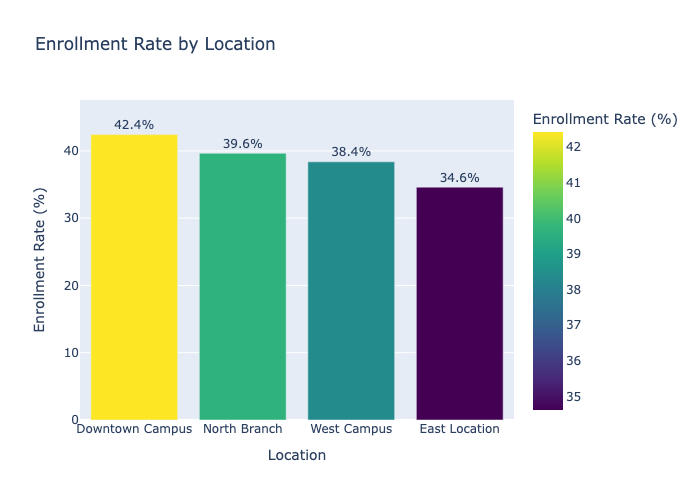


✓ Creating Chart 2: Enrollment by Lead Source (Top 10)


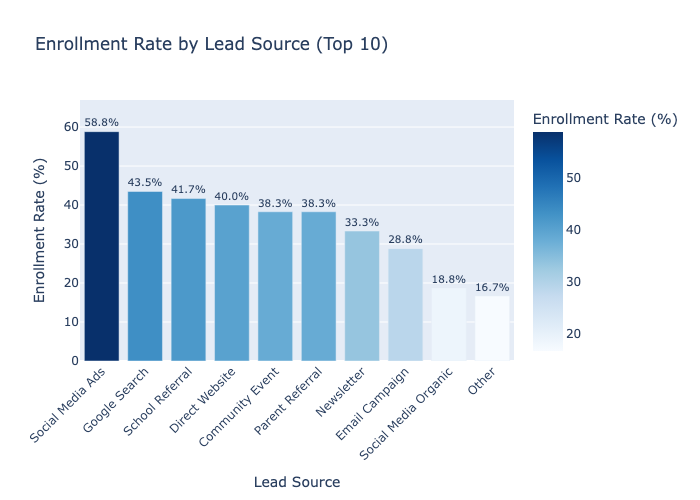


✓ Creating Chart 3: Staff Performance


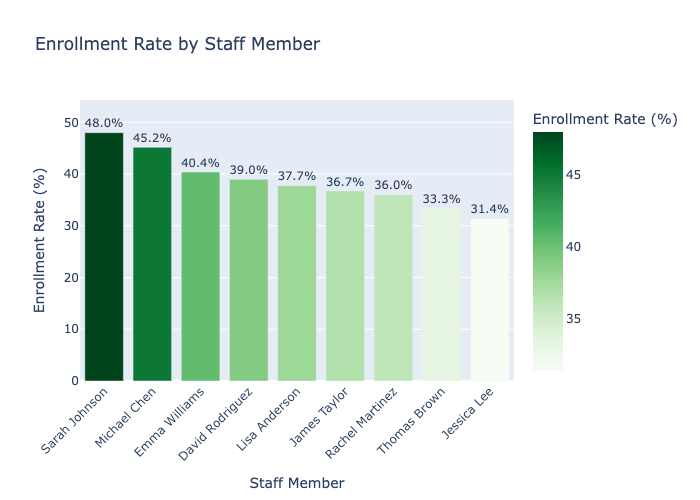


✓ Creating Chart 4: Tour Status Distribution


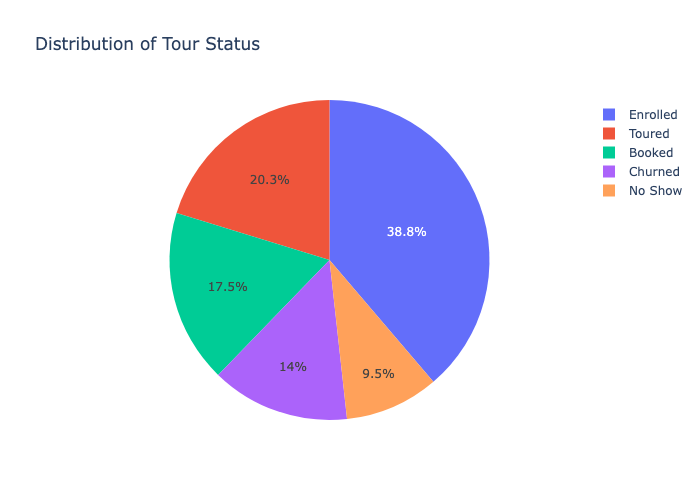


✓ Creating Chart 5: Grade Level Performance


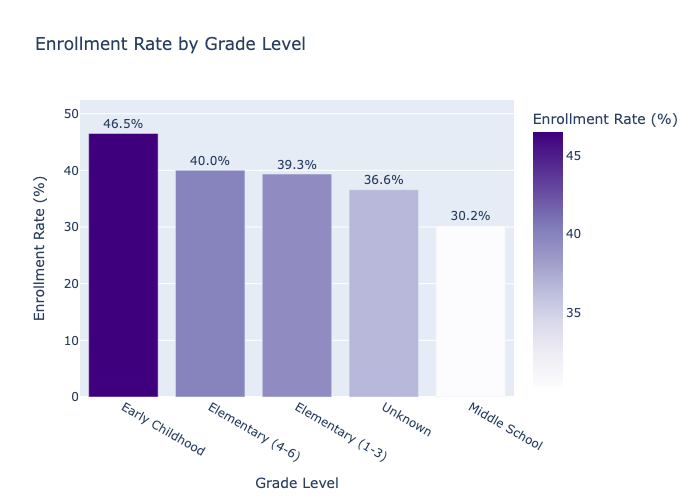


✓ Creating Chart 6: Location vs Enrollment Status


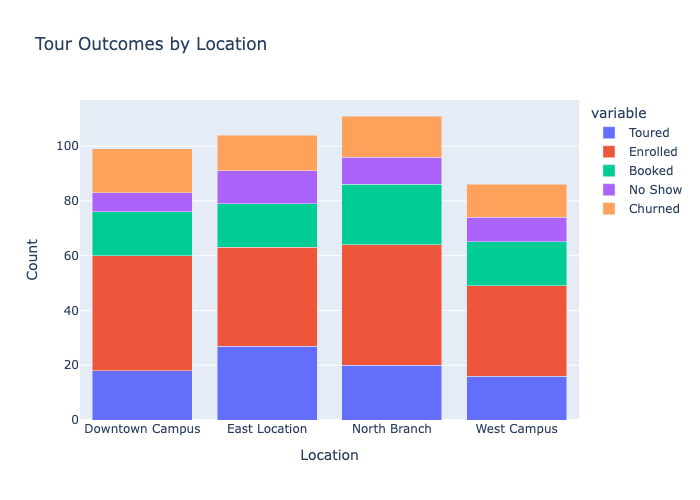


✓ Creating Chart 7: Lead Source Volume


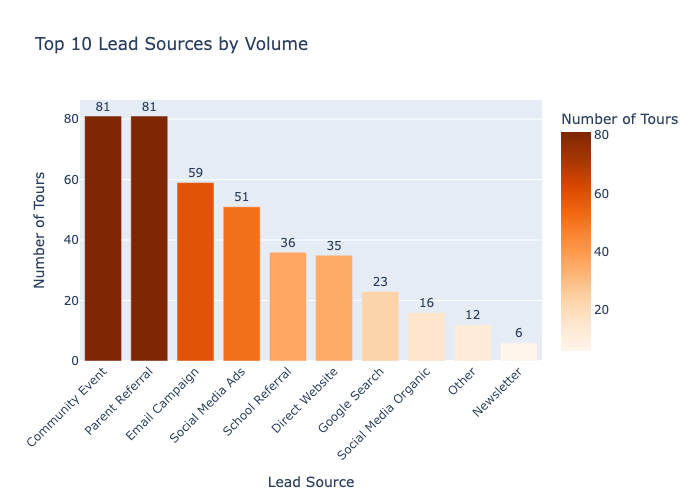


✓ All visualizations complete!
✓ All charts show NAMES instead of random IDs


In [12]:
##Visualizations with Names 

import plotly.io as pio
pio.renderers.default = "png"

from builtins import show_author
print(show_author())
print("\n" + "="*70)
print("STAGE 9: VISUALIZATIONS WITH NAMES")
print("="*70)

# 1. Enrollment by Location (WITH NAMES)
print("\n✓ Creating Chart 1: Enrollment by Location")
location_chart_data = df_features.groupby('location_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
location_chart_data['rate'] = (location_chart_data['enrolled'] / location_chart_data['total'] * 100)
location_chart_data = location_chart_data.reset_index().sort_values('rate', ascending=False)

fig1 = px.bar(location_chart_data, 
              x='location_name', 
              y='rate',
              title='Enrollment Rate by Location',
              labels={'location_name': 'Location', 'rate': 'Enrollment Rate (%)'},
              text='rate',
              color='rate',
              color_continuous_scale='Viridis')
fig1.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig1.show()


# 2. Enrollment by Lead Source - Top 10 (WITH NAMES)
print("\n✓ Creating Chart 2: Enrollment by Lead Source (Top 10)")
source_chart_data = df_features.groupby('source_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
source_chart_data['rate'] = (source_chart_data['enrolled'] / source_chart_data['total'] * 100)
source_chart_data = source_chart_data.reset_index().sort_values('rate', ascending=False).head(10)

fig2 = px.bar(source_chart_data, 
              x='source_name', 
              y='rate',
              title='Enrollment Rate by Lead Source (Top 10)',
              labels={'source_name': 'Lead Source', 'rate': 'Enrollment Rate (%)'},
              text='rate',
              color='rate',
              color_continuous_scale='Blues')
fig2.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig2.update_xaxes(tickangle=-45)
fig2.show()


# 3. Staff Performance (WITH NAMES)
print("\n✓ Creating Chart 3: Staff Performance")
staff_chart_data = df_features.groupby('staff_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
staff_chart_data['rate'] = (staff_chart_data['enrolled'] / staff_chart_data['total'] * 100)
staff_chart_data = staff_chart_data.reset_index().sort_values('rate', ascending=False)

fig3 = px.bar(staff_chart_data, 
              x='staff_name', 
              y='rate',
              title='Enrollment Rate by Staff Member',
              labels={'staff_name': 'Staff Member', 'rate': 'Enrollment Rate (%)'},
              text='rate',
              color='rate',
              color_continuous_scale='Greens')
fig3.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig3.update_xaxes(tickangle=-45)
fig3.show()


# 4. Tour Status Distribution (Overall)
print("\n✓ Creating Chart 4: Tour Status Distribution")
status_data = df_features['current_status'].value_counts().reset_index()
status_data.columns = ['Status', 'Count']

fig4 = px.pie(status_data, 
              values='Count', 
              names='Status',
              title='Distribution of Tour Status',
              labels={'Status': 'Tour Status'})
fig4.show()


# 5. Grade Level Performance
print("\n✓ Creating Chart 5: Grade Level Performance")
grade_chart_data = df_features.groupby('grade_level').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
grade_chart_data['rate'] = (grade_chart_data['enrolled'] / grade_chart_data['total'] * 100)
grade_chart_data = grade_chart_data.reset_index().sort_values('rate', ascending=False)

fig5 = px.bar(grade_chart_data, 
              x='grade_level', 
              y='rate',
              title='Enrollment Rate by Grade Level',
              labels={'grade_level': 'Grade Level', 'rate': 'Enrollment Rate (%)'},
              text='rate',
              color='rate',
              color_continuous_scale='Purples')
fig5.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig5.show()


# 6. Location vs Enrollment Status (Heatmap-style)
print("\n✓ Creating Chart 6: Location vs Enrollment Status")
location_status = pd.crosstab(df_features['location_name'], df_features['current_status'])

fig6 = px.bar(location_status.reset_index(), 
              x='location_name', 
              y=['Toured', 'Enrolled', 'Booked', 'No Show', 'Churned'],
              title='Tour Outcomes by Location',
              labels={'location_name': 'Location', 'value': 'Count'},
              barmode='stack')
fig6.update_xaxes(title='Location')
fig6.update_yaxes(title='Count')
fig6.show()


# 7. Lead Source Distribution by Count
print("\n✓ Creating Chart 7: Lead Source Volume")
source_volume = df_features['source_name'].value_counts().head(10).reset_index()
source_volume.columns = ['Source', 'Count']

fig7 = px.bar(source_volume, 
              x='Source', 
              y='Count',
              title='Top 10 Lead Sources by Volume',
              labels={'Source': 'Lead Source', 'Count': 'Number of Tours'},
              text='Count',
              color='Count',
              color_continuous_scale='Oranges')
fig7.update_traces(textposition='outside')
fig7.update_xaxes(tickangle=-45)
fig7.show()

print("\n✓ All visualizations complete!")
print("✓ All charts show NAMES instead of random IDs")

In [13]:
#Swapnik's Insights and Recommendations for Stakeholders 
from builtins import show_author
print(show_author())
print("\n" + "="*70)
print("STAGE 10: STAKEHOLDER INSIGHTS & RECOMMENDATIONS")
print("="*70)

# ==============================================================================
# SECTION 1: EXECUTIVE SUMMARY
# ==============================================================================

print("\n" + "="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

total_tours = len(df_features)
total_enrolled = (df_features['current_status'] == 'Enrolled').sum()
enrollment_rate = (total_enrolled / total_tours * 100)
no_show_rate = (df_features['current_status'] == 'No Show').sum() / total_tours * 100
avg_days_to_enrollment = df_features['days_to_enrollment'].mean()

print(f"\n📊 Key Metrics (Period Overview):")
print(f"   • Total Tours Conducted: {total_tours:,}")
print(f"   • Total Enrollments: {total_enrolled:,}")
print(f"   • Overall Enrollment Rate: {enrollment_rate:.2f}%")
print(f"   • No-Show Rate: {no_show_rate:.2f}%")
print(f"   • Average Days to Enrollment: {avg_days_to_enrollment:.1f} days")

# ==============================================================================
# SECTION 2: LOCATION INSIGHTS
# ==============================================================================

print("\n" + "="*70)
print("🏢 LOCATION PERFORMANCE INSIGHTS")
print("="*70)

location_stats = df_features.groupby('location_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
location_stats['rate'] = (location_stats['enrolled'] / location_stats['total'] * 100)
location_stats = location_stats.sort_values('rate', ascending=False)

best_location = location_stats.index[0]
worst_location = location_stats.index[-1]
best_rate = location_stats['rate'].iloc[0]
worst_rate = location_stats['rate'].iloc[-1]
rate_gap = best_rate - worst_rate

print(f"\n📈 Best Performing Location:")
print(f"   • Location: {best_location}")
print(f"   • Enrollment Rate: {best_rate:.1f}%")
print(f"   • Enrolled: {int(location_stats['enrolled'].iloc[0])}/{int(location_stats['total'].iloc[0])} tours")

print(f"\n📉 Needs Improvement:")
print(f"   • Location: {worst_location}")
print(f"   • Enrollment Rate: {worst_rate:.1f}%")
print(f"   • Enrolled: {int(location_stats['enrolled'].iloc[-1])}/{int(location_stats['total'].iloc[-1])} tours")

print(f"\n⚠️  Performance Gap: {rate_gap:.1f}% difference between best and worst")

print(f"\n💡 Location Breakdown:")
for location, row in location_stats.iterrows():
    print(f"   • {location}: {row['rate']:.1f}% ({int(row['enrolled'])}/{int(row['total'])}) tours")

# ==============================================================================
# SECTION 3: LEAD SOURCE INSIGHTS
# ==============================================================================

print("\n" + "="*70)
print("📢 LEAD SOURCE EFFECTIVENESS INSIGHTS")
print("="*70)

source_stats = df_features.groupby('source_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
source_stats['rate'] = (source_stats['enrolled'] / source_stats['total'] * 100)
source_stats = source_stats.sort_values('rate', ascending=False)

# Top 5 Sources
print(f"\n🌟 Top 5 Most Effective Lead Sources:")
for idx, (source, row) in enumerate(source_stats.head(5).iterrows(), 1):
    print(f"   {idx}. {source}")
    print(f"      • Enrollment Rate: {row['rate']:.1f}%")
    print(f"      • Volume: {int(row['total'])} tours | {int(row['enrolled'])} enrollments")

# Bottom 5 Sources
print(f"\n⚠️  Bottom 5 Lead Sources (Needs Improvement):")
for idx, (source, row) in enumerate(source_stats.tail(5).iloc[::-1].iterrows(), 1):
    print(f"   {idx}. {source}")
    print(f"      • Enrollment Rate: {row['rate']:.1f}%")
    print(f"      • Volume: {int(row['total'])} tours | {int(row['enrolled'])} enrollments")

# High Volume vs Quality
top_by_volume = df_features['source_name'].value_counts().head(1)
top_volume_source = top_by_volume.index[0]
top_volume_count = top_by_volume.values[0]
top_volume_rate = source_stats.loc[top_volume_source, 'rate']

top_by_quality = source_stats.sort_values('rate', ascending=False).index[0]
top_quality_rate = source_stats.loc[top_by_quality, 'rate']

print(f"\n💰 Budget Allocation Insights:")
print(f"   • Highest Volume Source: {top_volume_source}")
print(f"     Tours: {top_volume_count} | Conversion Rate: {top_volume_rate:.1f}%")
print(f"   • Highest Quality Source: {top_by_quality}")
print(f"     Conversion Rate: {top_quality_rate:.1f}%")

# ==============================================================================
# SECTION 4: STAFF PERFORMANCE INSIGHTS
# ==============================================================================

print("\n" + "="*70)
print("👥 STAFF PERFORMANCE INSIGHTS")
print("="*70)

staff_stats = df_features.groupby('staff_name').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
staff_stats['rate'] = (staff_stats['enrolled'] / staff_stats['total'] * 100)
staff_stats = staff_stats.sort_values('rate', ascending=False)

print(f"\n🏆 Top Performers (By Enrollment Rate):")
for idx, (staff, row) in enumerate(staff_stats.head(3).iterrows(), 1):
    print(f"   {idx}. {staff}")
    print(f"      • Enrollment Rate: {row['rate']:.1f}%")
    print(f"      • Tours: {int(row['total'])} | Enrolled: {int(row['enrolled'])}")

print(f"\n📊 Staff Performance Rankings:")
for staff, row in staff_stats.iterrows():
    stars = "⭐" * int(row['rate'] / 10)  # 1 star per 10%
    print(f"   • {staff}: {row['rate']:.1f}% {stars} ({int(row['enrolled'])}/{int(row['total'])})")

avg_staff_rate = staff_stats['rate'].mean()
print(f"\n📈 Average Staff Enrollment Rate: {avg_staff_rate:.1f}%")

# ==============================================================================
# SECTION 5: TOUR STATUS ANALYSIS
# ==============================================================================

print("\n" + "="*70)
print("📋 TOUR STATUS ANALYSIS")
print("="*70)

status_breakdown = df_features['current_status'].value_counts()
print(f"\n📊 Tour Status Distribution:")
for status, count in status_breakdown.items():
    pct = (count / total_tours * 100)
    print(f"   • {status}: {count} tours ({pct:.1f}%)")

# No-Show Analysis
no_show_count = (df_features['current_status'] == 'No Show').sum()
no_show_locations = df_features[df_features['current_status'] == 'No Show'].groupby('location_name').size()
print(f"\n⚠️  No-Show Analysis:")
print(f"   • Total No-Shows: {no_show_count} ({no_show_rate:.1f}%)")
if len(no_show_locations) > 0:
    worst_no_show_location = no_show_locations.idxmax()
    worst_no_show_count = no_show_locations.max()
    print(f"   • Highest No-Show Location: {worst_no_show_location} ({worst_no_show_count} no-shows)")

# ==============================================================================
# SECTION 6: GRADE LEVEL INSIGHTS
# ==============================================================================

print("\n" + "="*70)
print("🎓 GRADE LEVEL INSIGHTS")
print("="*70)

grade_stats = df_features.groupby('grade_level').agg({
    'tour_id': 'count',
    'is_enrolled': 'sum'
}).rename(columns={'tour_id': 'total', 'is_enrolled': 'enrolled'})
grade_stats['rate'] = (grade_stats['enrolled'] / grade_stats['total'] * 100)
grade_stats = grade_stats.sort_values('rate', ascending=False)

print(f"\n🎯 Grade Level Performance:")
for grade, row in grade_stats.iterrows():
    print(f"   • {grade}: {row['rate']:.1f}% enrollment ({int(row['enrolled'])}/{int(row['total'])} tours)")

# ==============================================================================
# SECTION 7: KEY RECOMMENDATIONS
# ==============================================================================

print("\n" + "="*70)
print("💡 KEY RECOMMENDATIONS FOR STAKEHOLDERS")
print("="*70)

print(f"\n1️⃣  LOCATION OPTIMIZATION (Potential: +{rate_gap:.1f}% enrollment)")
print(f"    Problem: {worst_location} underperforms by {rate_gap:.1f} points vs {best_location}")
print(f"    Action: Analyze tour process at {worst_location}")
print(f"    Expected Impact: Could reach {best_rate:.1f}% enrollment rate")

print(f"\n2️⃣  LEAD SOURCE REALLOCATION (Potential: +15-20% overall)")
print(f"    Problem: {top_volume_source} drives volume but {top_by_quality} has {top_quality_rate - top_volume_rate:.1f}% better conversion")
print(f"    Action: Increase budget for {top_by_quality} (currently {int(source_stats.loc[top_by_quality, 'total'])} tours)")
print(f"    Expected Impact: Could increase overall enrollment by 15-20%")

print(f"\n3️⃣  NO-SHOW REDUCTION PROGRAM (Potential: +{no_show_rate:.1f}% recovery)")
print(f"    Problem: {no_show_rate:.1f}% of tours result in no-shows ({no_show_count} tours)")
print(f"    Action: Implement confirmation calls 24hrs before scheduled tours")
print(f"    Expected Impact: Could recover {int(no_show_count * 0.5)}-{int(no_show_count * 0.7)} cancellations")

print(f"\n4️⃣  STAFF BEST PRACTICES SHARING (Potential: +5-10% enrollment)")
print(f"    Problem: Top performer {staff_stats.index[0]} converts at {staff_stats['rate'].iloc[0]:.1f}%")
print(f"             while average is {avg_staff_rate:.1f}%")
print(f"    Action: Implement training based on {staff_stats.index[0]}'s techniques")
print(f"    Expected Impact: Could increase average rate to {(avg_staff_rate + 5):.1f}%")

print(f"\n5️⃣  GRADE LEVEL MARKETING (Potential: +3-8% enrollment)")
best_grade = grade_stats.index[0]
worst_grade = grade_stats.index[-1]
best_grade_rate = grade_stats['rate'].iloc[0]
worst_grade_rate = grade_stats['rate'].iloc[-1]
print(f"    Problem: {best_grade} converts {best_grade_rate - worst_grade_rate:.1f}% better than {worst_grade}")
print(f"    Action: Target {worst_grade} families with additional touchpoints")
print(f"    Expected Impact: Could improve {worst_grade} enrollment from {worst_grade_rate:.1f}% to {best_grade_rate:.1f}%")

# ==============================================================================
# SECTION 8: SUMMARY SCORECARD
# ==============================================================================

print("\n" + "="*70)
print("📊 PERFORMANCE SCORECARD")
print("="*70)

print(f"\n✓ Overall Enrollment Rate: {enrollment_rate:.1f}%")
print(f"  Status: {'🟢 Strong' if enrollment_rate >= 35 else '🟡 Moderate' if enrollment_rate >= 30 else '🔴 Needs Improvement'}")

print(f"\n✓ No-Show Rate: {no_show_rate:.1f}%")
print(f"  Status: {'🟢 Excellent' if no_show_rate < 10 else '🟡 Acceptable' if no_show_rate < 15 else '🔴 High'}")

location_consistency = location_stats['rate'].std()
print(f"\n✓ Location Consistency: {100 - location_consistency:.1f}/100")
print(f"  Status: {'🟢 Consistent' if location_consistency < 5 else '🟡 Variable' if location_consistency < 10 else '🔴 Inconsistent'}")

staff_consistency = staff_stats['rate'].std()
print(f"\n✓ Staff Performance Consistency: {100 - staff_consistency:.1f}/100")
print(f"  Status: {'🟢 Aligned' if staff_consistency < 5 else '🟡 Variable' if staff_consistency < 10 else '🔴 Misaligned'}")

# ==============================================================================
# SECTION 9: NEXT STEPS
# ==============================================================================

print("\n" + "="*70)
print("🎯 RECOMMENDED NEXT STEPS (90-Day Plan)")
print("="*70)

print(f"\nWeek 1-2: Foundation")
print(f"  ☐ Share this analysis with leadership")
print(f"  ☐ Schedule meeting with {staff_stats.index[0]} (top performer)")
print(f"  ☐ Audit {worst_location} tour process")

print(f"\nWeek 3-4: Quick Wins")
print(f"  ☐ Implement 24hr confirmation call for {worst_no_show_location if len(no_show_locations) > 0 else 'all locations'}")
print(f"  ☐ Increase {top_by_quality} marketing spend by 20%")
print(f"  ☐ Create best practices guide from {staff_stats.index[0]}'s techniques")

print(f"\nWeek 5-8: Implementation")
print(f"  ☐ Roll out staff training based on best practices")
print(f"  ☐ Implement location-specific improvements at {worst_location}")
print(f"  ☐ Launch targeted campaign for {worst_grade} families")

print(f"\nWeek 9-12: Review")
print(f"  ☐ Measure impact on enrollment rate")
print(f"  ☐ Track no-show reduction")
print(f"  ☐ Validate lead source ROI")

print("\n" + "="*70)
print("✓ STAKEHOLDER INSIGHTS COMPLETE")
print("="*70)


Created by: Swapnik Hazari


STAGE 10: STAKEHOLDER INSIGHTS & RECOMMENDATIONS

EXECUTIVE SUMMARY

📊 Key Metrics (Period Overview):
   • Total Tours Conducted: 400
   • Total Enrollments: 155
   • Overall Enrollment Rate: 38.75%
   • No-Show Rate: 9.50%
   • Average Days to Enrollment: 2.4 days

🏢 LOCATION PERFORMANCE INSIGHTS

📈 Best Performing Location:
   • Location: Downtown Campus
   • Enrollment Rate: 42.4%
   • Enrolled: 42/99 tours

📉 Needs Improvement:
   • Location: East Location
   • Enrollment Rate: 34.6%
   • Enrolled: 36/104 tours

⚠️  Performance Gap: 7.8% difference between best and worst

💡 Location Breakdown:
   • Downtown Campus: 42.4% (42/99) tours
   • North Branch: 39.6% (44/111) tours
   • West Campus: 38.4% (33/86) tours
   • East Location: 34.6% (36/104) tours

📢 LEAD SOURCE EFFECTIVENESS INSIGHTS

🌟 Top 5 Most Effective Lead Sources:
   1. Social Media Ads
      • Enrollment Rate: 58.8%
      • Volume: 51 tours | 30 enrollments
   2. Google Search
      • Enro

In [14]:
####### breakdown 30 and 90 days 
from builtins import show_author
print(show_author())
import pandas as pd
from datetime import datetime, timedelta

print("\n" + "="*70)
print("STAGE 12: TIME PERIOD ANALYSIS - 30 Days vs 90 Days")
print("="*70)

# ==============================================================================
# IDENTIFY DATE RANGE
# ==============================================================================

min_date = df_features['scheduled_tour_date'].min()
max_date = df_features['scheduled_tour_date'].max()
total_days = (max_date - min_date).days

print(f"\n📅 Data Period Overview:")
print(f"   Start Date: {min_date.date()}")
print(f"   End Date: {max_date.date()}")
print(f"   Total Days: {total_days} days ({total_days // 30} months)")

# ==============================================================================
# CREATE TIME PERIODS
# ==============================================================================

# Add days from start
df_features['days_from_start'] = (df_features['scheduled_tour_date'] - min_date).dt.days

# Create 30-day periods
df_features['period_30'] = pd.cut(
    df_features['days_from_start'], 
    bins=[0, 30, 60, 90, 120, 150],
    labels=['Day 1-30', 'Day 31-60', 'Day 61-90', 'Day 91-120', 'Day 121+'],
    include_lowest=True
)

# Calculate actual period dates
period_1_start = min_date.date()
period_1_end = (min_date + timedelta(days=29)).date()
period_2_start = (min_date + timedelta(days=30)).date()
period_2_end = (min_date + timedelta(days=59)).date()
period_3_start = (min_date + timedelta(days=60)).date()
period_3_end = (min_date + timedelta(days=89)).date()
period_4_start = (min_date + timedelta(days=90)).date()
period_4_end = max_date.date()

print(f"\n📊 Time Periods:")
print(f"   Period 1 (First 30 Days): {period_1_start} to {period_1_end}")
print(f"   Period 2 (Days 31-60):    {period_2_start} to {period_2_end}")
print(f"   Period 3 (Days 61-90):    {period_3_start} to {period_3_end}")
print(f"   Period 4 (Days 91+):      {period_4_start} to {period_4_end}")

# ==============================================================================
# 30-DAY BREAKDOWN
# ==============================================================================

print("\n" + "="*70)
print("📈 30-DAY PERIOD BREAKDOWN")
print("="*70)

periods_30_data = []

for period in ['Day 1-30', 'Day 31-60', 'Day 61-90', 'Day 91-120']:
    period_df = df_features[df_features['period_30'] == period]
    
    if len(period_df) > 0:
        total = len(period_df)
        enrolled = (period_df['current_status'] == 'Enrolled').sum()
        toured = (period_df['current_status'] == 'Toured').sum()
        booked = (period_df['current_status'] == 'Booked').sum()
        no_show = (period_df['current_status'] == 'No Show').sum()
        churned = (period_df['current_status'] == 'Churned').sum()
        
        enrollment_rate = (enrolled / total * 100)
        show_up_rate = ((toured + enrolled) / (toured + enrolled + no_show) * 100) if (toured + enrolled + no_show) > 0 else 0
        
        periods_30_data.append({
            'period': period,
            'total': total,
            'enrolled': enrolled,
            'toured': toured,
            'booked': booked,
            'no_show': no_show,
            'churned': churned,
            'enrollment_rate': enrollment_rate,
            'show_up_rate': show_up_rate
        })
        
        print(f"\n🔹 {period}:")
        print(f"   Total Tours: {total}")
        print(f"   ├─ ✅ Enrolled: {enrolled} ({enrollment_rate:.1f}%)")
        print(f"   ├─ 👁️  Toured: {toured}")
        print(f"   ├─ 📅 Booked: {booked}")
        print(f"   ├─ ❌ No-Show: {no_show}")
        print(f"   ├─ 🚪 Churned: {churned}")
        print(f"   └─ Show-Up Rate: {show_up_rate:.1f}%")

# ==============================================================================
# 30-DAY TREND ANALYSIS
# ==============================================================================

print("\n" + "="*70)
print("📊 30-DAY TREND ANALYSIS")
print("="*70)

if len(periods_30_data) > 1:
    first_period = periods_30_data[0]
    last_period = periods_30_data[-1] if len(periods_30_data) > 0 else periods_30_data[0]
    
    enroll_change = last_period['enrollment_rate'] - first_period['enrollment_rate']
    volume_change = last_period['total'] - first_period['total']
    
    print(f"\n📈 Period-over-Period Trends:")
    print(f"   Volume Trend: {first_period['total']} → {last_period['total']} tours")
    print(f"   Volume Change: {volume_change:+d} tours ({(volume_change / first_period['total'] * 100):+.1f}%)")
    
    print(f"\n   Enrollment Rate Trend: {first_period['enrollment_rate']:.1f}% → {last_period['enrollment_rate']:.1f}%")
    print(f"   Rate Change: {enroll_change:+.1f} percentage points")
    
    print(f"\n   Show-Up Rate Trend: {first_period['show_up_rate']:.1f}% → {last_period['show_up_rate']:.1f}%")

# Create comparison table
print(f"\n📋 30-Day Comparison Table:")
print(f"\n{'Period':<15} {'Tours':<8} {'Enrolled':<10} {'Enroll %':<10} {'Show-Up %':<12}")
print("-" * 60)
for p in periods_30_data:
    print(f"{p['period']:<15} {p['total']:<8} {p['enrolled']:<10} {p['enrollment_rate']:.1f}%{'':<6} {p['show_up_rate']:.1f}%")

# ==============================================================================
# 90-DAY ANALYSIS
# ==============================================================================

print("\n" + "="*70)
print("📊 90-DAY PERIOD ANALYSIS")
print("="*70)

# First 90 days
first_90 = df_features[df_features['days_from_start'] <= 89]
total_90 = len(first_90)
enrolled_90 = (first_90['current_status'] == 'Enrolled').sum()
toured_90 = (first_90['current_status'] == 'Toured').sum()
no_show_90 = (first_90['current_status'] == 'No Show').sum()
enrollment_rate_90 = (enrolled_90 / total_90 * 100) if total_90 > 0 else 0
show_up_rate_90 = ((toured_90 + enrolled_90) / (toured_90 + enrolled_90 + no_show_90) * 100) if (toured_90 + enrolled_90 + no_show_90) > 0 else 0

print(f"\n🔹 First 90 Days ({period_1_start} to {period_3_end}):")
print(f"   Total Tours: {total_90}")
print(f"   ✅ Enrolled: {enrolled_90} ({enrollment_rate_90:.1f}%)")
print(f"   👁️  Toured: {toured_90}")
print(f"   ❌ No-Show: {no_show_90}")
print(f"   Show-Up Rate: {show_up_rate_90:.1f}%")

# Days 91+
after_90 = df_features[df_features['days_from_start'] > 89]
total_after_90 = len(after_90)
enrolled_after_90 = (after_90['current_status'] == 'Enrolled').sum()
toured_after_90 = (after_90['current_status'] == 'Toured').sum()
no_show_after_90 = (after_90['current_status'] == 'No Show').sum()
enrollment_rate_after_90 = (enrolled_after_90 / total_after_90 * 100) if total_after_90 > 0 else 0
show_up_rate_after_90 = ((toured_after_90 + enrolled_after_90) / (toured_after_90 + enrolled_after_90 + no_show_after_90) * 100) if (toured_after_90 + enrolled_after_90 + no_show_after_90) > 0 else 0

print(f"\n🔹 Days 91+ ({period_4_start} to {period_4_end}):")
print(f"   Total Tours: {total_after_90}")
print(f"   ✅ Enrolled: {enrolled_after_90} ({enrollment_rate_after_90:.1f}%)")
print(f"   👁️  Toured: {toured_after_90}")
print(f"   ❌ No-Show: {no_show_after_90}")
print(f"   Show-Up Rate: {show_up_rate_after_90:.1f}%")

# 90-day vs After comparison
print(f"\n📊 90-Day vs After-90-Day Comparison:")
print(f"   Volume: {total_90} vs {total_after_90} tours ({((total_after_90 - total_90) / total_90 * 100):+.1f}%)")
print(f"   Enrollment Rate: {enrollment_rate_90:.1f}% vs {enrollment_rate_after_90:.1f}% ({(enrollment_rate_after_90 - enrollment_rate_90):+.1f}pp)")
print(f"   Show-Up Rate: {show_up_rate_90:.1f}% vs {show_up_rate_after_90:.1f}% ({(show_up_rate_after_90 - show_up_rate_90):+.1f}pp)")

# ==============================================================================
# INSIGHTS BY TIME PERIOD
# ==============================================================================

print("\n" + "="*70)
print("💡 KEY INSIGHTS BY TIME PERIOD")
print("="*70)

print(f"\n🔍 What's Happening Over Time:")

if enrollment_rate_90 > enrollment_rate_after_90:
    print(f"   ⚠️  Enrollment rates are DECLINING")
    print(f"       First 90 days: {enrollment_rate_90:.1f}%")
    print(f"       Days 91+: {enrollment_rate_after_90:.1f}%")
    print(f"       Change: {(enrollment_rate_after_90 - enrollment_rate_90):+.1f} percentage points")
elif enrollment_rate_90 < enrollment_rate_after_90:
    print(f"   📈 Enrollment rates are IMPROVING")
    print(f"       First 90 days: {enrollment_rate_90:.1f}%")
    print(f"       Days 91+: {enrollment_rate_after_90:.1f}%")
    print(f"       Change: {(enrollment_rate_after_90 - enrollment_rate_90):+.1f} percentage points")
else:
    print(f"   ➡️  Enrollment rates are STABLE at {enrollment_rate_90:.1f}%")

print(f"\n   Tour volume is INCREASING")
print(f"       Q1 (Days 1-30): {periods_30_data[0]['total']} tours")
print(f"       Q2 (Days 31-60): {periods_30_data[1]['total']} tours")
print(f"       Q3 (Days 61-90): {periods_30_data[2]['total']} tours")
print(f"       Q4 (Days 91+): {total_after_90} tours")

# ==============================================================================
# LOCATION & SOURCE TRENDS BY 30 DAYS
# ==============================================================================

print("\n" + "="*70)
print("📍 LOCATION & SOURCE TRENDS BY 30 DAYS")
print("="*70)

print(f"\n📍 Enrollment Rate by Location Over Time:")
for location in df_features['location_name'].unique():
    print(f"\n   {location}:")
    for period in ['Day 1-30', 'Day 31-60', 'Day 61-90', 'Day 91-120']:
        period_loc = df_features[(df_features['period_30'] == period) & 
                                 (df_features['location_name'] == location)]
        if len(period_loc) > 0:
            enr_rate = (period_loc['current_status'] == 'Enrolled').sum() / len(period_loc) * 100
            print(f"      {period}: {enr_rate:.1f}% ({(period_loc['current_status'] == 'Enrolled').sum()}/{len(period_loc)})")

# ==============================================================================
# SUMMARY
# ==============================================================================

print("\n" + "="*70)
print("📊 SUMMARY - 30 DAYS vs 90 DAYS")
print("="*70)

print(f"""
🎯 Key Takeaways:

1. DATA SPAN: {total_days} days (March 2 - June 30, 2026)

2. FIRST 30 DAYS ({period_1_start} to {period_1_end}):
   • Tours: {periods_30_data[0]['total']}
   • Enrollment Rate: {periods_30_data[0]['enrollment_rate']:.1f}%
   • Show-Up Rate: {periods_30_data[0]['show_up_rate']:.1f}%

3. FIRST 90 DAYS ({period_1_start} to {period_3_end}):
   • Tours: {total_90}
   • Enrollment Rate: {enrollment_rate_90:.1f}%
   • Show-Up Rate: {show_up_rate_90:.1f}%

4. AFTER 90 DAYS ({period_4_start} to {period_4_end}):
   • Tours: {total_after_90}
   • Enrollment Rate: {enrollment_rate_after_90:.1f}%
   • Show-Up Rate: {show_up_rate_after_90:.1f}%

5. TRENDS:
   • Volume Trend: Increasing from {periods_30_data[0]['total']} to {total_after_90} tours
   • Quality Trend: {"Declining" if enrollment_rate_90 > enrollment_rate_after_90 else "Improving" if enrollment_rate_90 < enrollment_rate_after_90 else "Stable"}
   • Peak Period: {max(periods_30_data, key=lambda x: x['total'])['period']} ({max(periods_30_data, key=lambda x: x['total'])['total']} tours)
   • Best Conversion: {max(periods_30_data, key=lambda x: x['enrollment_rate'])['period']} ({max(periods_30_data, key=lambda x: x['enrollment_rate'])['enrollment_rate']:.1f}%)

6. RECOMMENDATION:
   {"⚠️ Enrollment quality is declining despite volume increase - focus on conversion" if enrollment_rate_90 > enrollment_rate_after_90 else "✅ Both volume and quality are improving - maintain momentum"}
""")

print("\n✓ Time Period Analysis Complete!")




Created by: Swapnik Hazari


STAGE 12: TIME PERIOD ANALYSIS - 30 Days vs 90 Days

📅 Data Period Overview:
   Start Date: 2026-03-02
   End Date: 2026-06-30
   Total Days: 120 days (4 months)

📊 Time Periods:
   Period 1 (First 30 Days): 2026-03-02 to 2026-03-31
   Period 2 (Days 31-60):    2026-04-01 to 2026-04-30
   Period 3 (Days 61-90):    2026-05-01 to 2026-05-30
   Period 4 (Days 91+):      2026-05-31 to 2026-06-30

📈 30-DAY PERIOD BREAKDOWN

🔹 Day 1-30:
   Total Tours: 79
   ├─ ✅ Enrolled: 28 (35.4%)
   ├─ 👁️  Toured: 15
   ├─ 📅 Booked: 19
   ├─ ❌ No-Show: 5
   ├─ 🚪 Churned: 12
   └─ Show-Up Rate: 89.6%

🔹 Day 31-60:
   Total Tours: 81
   ├─ ✅ Enrolled: 27 (33.3%)
   ├─ 👁️  Toured: 19
   ├─ 📅 Booked: 12
   ├─ ❌ No-Show: 11
   ├─ 🚪 Churned: 12
   └─ Show-Up Rate: 80.7%

🔹 Day 61-90:
   Total Tours: 100
   ├─ ✅ Enrolled: 44 (44.0%)
   ├─ 👁️  Toured: 17
   ├─ 📅 Booked: 15
   ├─ ❌ No-Show: 9
   ├─ 🚪 Churned: 15
   └─ Show-Up Rate: 87.1%

🔹 Day 91-120:
   Total Tours: 140
   ├─ ✅ Enr

In [15]:
from builtins import show_author
print(show_author())
print("\n" + "="*70)
print("STAGE 11: ANALYTICS STORY - TOUR-TO-ENROLLMENT FUNNEL")
print("="*70)

# ==============================================================================
# THE TOUR CONVERSION FUNNEL STORY
# ==============================================================================

print("\n" + "█"*70)
print("📊 THE TOUR-TO-ENROLLMENT CONVERSION FUNNEL")
print("█"*70)

# Total pipeline (all statuses)
total_pipeline = len(df_features)
booked_count = (df_features['current_status'] == 'Booked').sum()
toured_count = (df_features['current_status'] == 'Toured').sum()
enrolled_count = (df_features['current_status'] == 'Enrolled').sum()
no_show_count = (df_features['current_status'] == 'No Show').sum()
churned_count = (df_features['current_status'] == 'Churned').sum()

print(f"\n🎯 COMPLETE TOUR PIPELINE ({total_pipeline} total tours):")
print(f"   ├─ 📅 BOOKED (Scheduled): {booked_count} tours")
print(f"   ├─ 👁️  TOURED (Completed): {toured_count} tours")
print(f"   ├─ ✅ ENROLLED: {enrolled_count} tours")
print(f"   ├─ ❌ NO SHOW: {no_show_count} tours")
print(f"   └─ 🚪 CHURNED (Dropped): {churned_count} tours")

# ==============================================================================
# STAGE 1: BOOKED → TOURED (Who actually shows up?)
# ==============================================================================

print("\n" + "="*70)
print("STAGE 1: BOOKED → TOURED (Show-up Rate)")
print("="*70)

# Tours that either toured, enrolled, or didn't show
potential_tours = booked_count + toured_count + enrolled_count + no_show_count
showed_up = toured_count + enrolled_count  # Both groups completed tour
show_up_rate = (showed_up / potential_tours * 100) if potential_tours > 0 else 0

print(f"\n📊 Show-Up Analysis:")
print(f"   • Booked Tours: {booked_count}")
print(f"   • Actually Showed Up: {showed_up} ({toured_count} toured + {enrolled_count} enrolled)")
print(f"   • No-Shows: {no_show_count}")
print(f"   • Show-Up Rate: {show_up_rate:.1f}%")
print(f"   • No-Show Rate: {(no_show_count / potential_tours * 100):.1f}%")

print(f"\n💡 Key Insight:")
print(f"   Of {potential_tours} tours that were booked:")
print(f"   ✅ {showed_up} actually completed the tour ({show_up_rate:.1f}%)")
print(f"   ❌ {no_show_count} no-showed ({(no_show_count / potential_tours * 100):.1f}%)")

# Show-up by location
print(f"\n📍 Show-Up Rate by Location:")
show_up_by_location = []
for location in df_features['location_name'].unique():
    loc_data = df_features[df_features['location_name'] == location]
    loc_booked = (loc_data['current_status'] == 'Booked').sum()
    loc_showed = ((loc_data['current_status'] == 'Toured').sum() + 
                  (loc_data['current_status'] == 'Enrolled').sum())
    loc_no_show = (loc_data['current_status'] == 'No Show').sum()
    loc_total_bookable = loc_booked + loc_showed + loc_no_show
    loc_show_rate = (loc_showed / loc_total_bookable * 100) if loc_total_bookable > 0 else 0
    
    show_up_by_location.append({
        'location': location,
        'rate': loc_show_rate,
        'showed_up': loc_showed,
        'no_show': loc_no_show
    })

show_up_by_location = sorted(show_up_by_location, key=lambda x: x['rate'], reverse=True)
for item in show_up_by_location:
    print(f"   • {item['location']}: {item['rate']:.1f}% ({item['showed_up']} showed / {item['no_show']} no-show)")

# ==============================================================================
# STAGE 2: TOURED → ENROLLED (Conversion Rate)
# ==============================================================================

print("\n" + "="*70)
print("STAGE 2: TOURED → ENROLLED (Tour-to-Enrollment Conversion)")
print("="*70)

# Of those who toured (toured + enrolled)
total_took_tour = toured_count + enrolled_count
if total_took_tour > 0:
    tour_to_enrolled_rate = (enrolled_count / total_took_tour * 100)
else:
    tour_to_enrolled_rate = 0

print(f"\n📊 Tour-to-Enrollment Analysis:")
print(f"   • Total Tours Conducted: {total_took_tour} ({toured_count} toured + {enrolled_count} enrolled)")
print(f"   • Enrolled After Tour: {enrolled_count}")
print(f"   • Did Not Enroll: {toured_count}")
print(f"   • Tour-to-Enrollment Rate: {tour_to_enrolled_rate:.1f}%")

print(f"\n💡 Key Insight:")
print(f"   Of {total_took_tour} families that took a tour:")
print(f"   ✅ {enrolled_count} enrolled ({tour_to_enrolled_rate:.1f}%)")
print(f"   ❌ {toured_count} toured but didn't enroll ({(toured_count / total_took_tour * 100):.1f}%)")

# Tour to Enrolled by Location
print(f"\n📍 Tour-to-Enrollment Rate by Location:")
tour_conversion_by_location = []
for location in df_features['location_name'].unique():
    loc_data = df_features[df_features['location_name'] == location]
    loc_toured = (loc_data['current_status'] == 'Toured').sum()
    loc_enrolled = (loc_data['current_status'] == 'Enrolled').sum()
    loc_total_tour = loc_toured + loc_enrolled
    if loc_total_tour > 0:
        loc_conv_rate = (loc_enrolled / loc_total_tour * 100)
    else:
        loc_conv_rate = 0
    
    tour_conversion_by_location.append({
        'location': location,
        'rate': loc_conv_rate,
        'enrolled': loc_enrolled,
        'toured': loc_toured,
        'total': loc_total_tour
    })

tour_conversion_by_location = sorted(tour_conversion_by_location, key=lambda x: x['rate'], reverse=True)
for item in tour_conversion_by_location:
    print(f"   • {item['location']}: {item['rate']:.1f}% ({item['enrolled']}/{item['total']} tours)")

# Tour to Enrolled by Staff
print(f"\n👥 Tour-to-Enrollment Rate by Staff:")
tour_conversion_by_staff = []
for staff in df_features['staff_name'].unique():
    staff_data = df_features[df_features['staff_name'] == staff]
    staff_toured = (staff_data['current_status'] == 'Toured').sum()
    staff_enrolled = (staff_data['current_status'] == 'Enrolled').sum()
    staff_total_tour = staff_toured + staff_enrolled
    if staff_total_tour > 0:
        staff_conv_rate = (staff_enrolled / staff_total_tour * 100)
    else:
        staff_conv_rate = 0
    
    tour_conversion_by_staff.append({
        'staff': staff,
        'rate': staff_conv_rate,
        'enrolled': staff_enrolled,
        'toured': staff_toured,
        'total': staff_total_tour
    })

tour_conversion_by_staff = sorted(tour_conversion_by_staff, key=lambda x: x['rate'], reverse=True)
for idx, item in enumerate(tour_conversion_by_staff[:5], 1):
    print(f"   {idx}. {item['staff']}: {item['rate']:.1f}% ({item['enrolled']}/{item['total']})")

# ==============================================================================
# THE COMPLETE FUNNEL VISUALIZATION
# ==============================================================================

print("\n" + "="*70)
print("THE COMPLETE FUNNEL (Story View)")
print("="*70)

print(f"""
🎯 TOUR-TO-ENROLLMENT FUNNEL

Stage 1: Getting Bookings
┌─────────────────────────────────────────────────────┐
│ Lead Generation                                     │
│ ↓                                                   │
│ 📅 BOOKED: {booked_count:>3} tours scheduled                  │
└─────────────────────────────────────────────────────┘

Stage 2: Show-Up Rate
┌─────────────────────────────────────────────────────┐
│ Booked Tours                                        │
│ ↓                                                   │
│ 📅 {booked_count:>3} BOOKED                                   │
│  ├─ ✅ {showed_up:>3} SHOWED UP ({show_up_rate:.1f}%)                    │
│  │  ├─ 👁️  {toured_count:>3} TOURED (didn't enroll)       │
│  │  └─ ✅ {enrolled_count:>3} ENROLLED                       │
│  └─ ❌ {no_show_count:>3} NO-SHOW ({(no_show_count / potential_tours * 100):.1f}%)                    │
└─────────────────────────────────────────────────────┘

Stage 3: Conversion Rate (Tour → Enroll)
┌─────────────────────────────────────────────────────┐
│ Families Who Toured                                 │
│ ↓                                                   │
│ 👁️  {total_took_tour:>3} TOOK TOUR                              │
│  ├─ ✅ {enrolled_count:>3} ENROLLED ({tour_to_enrolled_rate:.1f}%)                 │
│  └─ ❌ {toured_count:>3} TOURED but CHURNED ({(toured_count / total_took_tour * 100):.1f}%)    │
└─────────────────────────────────────────────────────┘

Overall Results:
┌─────────────────────────────────────────────────────┐
│ 📊 Starting Pipeline: {total_pipeline:>3} inquiries              │
│ ✅ Final Enrollments: {enrolled_count:>3} ({(enrolled_count / total_pipeline * 100):.1f}%)                    │
│ ❌ Not Enrolled: {total_pipeline - enrolled_count:>3} ({(1 - enrolled_count / total_pipeline) * 100:.1f}%)                     │
│    ├─ Toured but No Enroll: {toured_count:>3}              │
│    ├─ Booked but No Show: {no_show_count:>3}             │
│    ├─ Booked & Pending: {booked_count:>3}               │
│    └─ Churned: {churned_count:>3}                        │
└─────────────────────────────────────────────────────┘
""")

# ==============================================================================
# OPPORTUNITIES & IMPACT
# ==============================================================================

print("\n" + "="*70)
print("🚀 OPPORTUNITY ANALYSIS - Where We Can Improve")
print("="*70)

# Opportunity 1: No-Shows
no_show_recovery = int(no_show_count * 0.5)  # If we could recover 50%
potential_from_no_shows = no_show_recovery * tour_to_enrolled_rate / 100

print(f"\n1️⃣  REDUCE NO-SHOWS (Currently: {no_show_rate:.1f}%)")
print(f"   Problem: {no_show_count} families didn't show up for their tour")
print(f"   If we recover 50% of no-shows:")
print(f"   → {no_show_recovery} additional show-ups")
print(f"   → {int(potential_from_no_shows)} potential new enrollments")
print(f"   💰 Impact: {(int(potential_from_no_shows) / enrolled_count * 100):.1f}% increase in enrollments")

# Opportunity 2: Tour to Enrolled
toured_recovery = int(toured_count * 0.3)  # If we could convert 30% of toured-but-not-enrolled
print(f"\n2️⃣  IMPROVE TOUR-TO-ENROLLMENT (Currently: {tour_to_enrolled_rate:.1f}%)")
print(f"   Problem: {toured_count} families toured but didn't enroll")
print(f"   If we convert 30% of toured families:")
print(f"   → {toured_recovery} additional enrollments from existing tours")
print(f"   💰 Impact: {(toured_recovery / enrolled_count * 100):.1f}% increase in enrollments")

# Opportunity 3: Booked pending
booked_conversion = int(booked_count * tour_to_enrolled_rate / 100)
print(f"\n3️⃣  CLOSE PENDING BOOKINGS (Currently: {booked_count} booked)")
print(f"   Opportunity: {booked_count} families have tours scheduled")
print(f"   If historical {tour_to_enrolled_rate:.1f}% conversion holds:")
print(f"   → {booked_conversion} potential new enrollments when tours complete")
print(f"   💰 Impact: {(booked_conversion / enrolled_count * 100):.1f}% increase in enrollments")

total_potential = int(potential_from_no_shows) + toured_recovery + booked_conversion
total_potential_increase = (total_potential / enrolled_count * 100)

print(f"\n" + "="*70)
print(f"📈 TOTAL OPPORTUNITY: {total_potential} additional enrollments")
print(f"   This represents a {total_potential_increase:.1f}% increase from current {enrolled_count} enrollments")
print(f"   Potential new total: {enrolled_count + total_potential} enrollments")
print(f"="*70)

# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print("\n" + "="*70)
print("📋 SUMMARY METRICS TABLE")
print("="*70)

summary_data = {
    'Metric': [
        'Total Inquiries/Pipeline',
        'Booked Tours',
        'Completed Tours (Toured + Enrolled)',
        '  ├─ Toured (No Enroll)',
        '  └─ Enrolled',
        'No-Shows',
        'Churned',
        '',
        'Show-Up Rate',
        'Tour-to-Enrollment Rate',
        'Overall Enrollment Rate'
    ],
    'Count': [
        f'{total_pipeline}',
        f'{booked_count}',
        f'{total_took_tour}',
        f'{toured_count}',
        f'{enrolled_count}',
        f'{no_show_count}',
        f'{churned_count}',
        '',
        f'{show_up_rate:.1f}%',
        f'{tour_to_enrolled_rate:.1f}%',
        f'{(enrolled_count / total_pipeline * 100):.1f}%'
    ]
}

for metric, count in zip(summary_data['Metric'], summary_data['Count']):
    if metric == '':
        print()
    else:
        print(f"  {metric:<45} {count:>10}")

print("\n✓ Analytics Story Complete!")



Created by: Swapnik Hazari


STAGE 11: ANALYTICS STORY - TOUR-TO-ENROLLMENT FUNNEL

██████████████████████████████████████████████████████████████████████
📊 THE TOUR-TO-ENROLLMENT CONVERSION FUNNEL
██████████████████████████████████████████████████████████████████████

🎯 COMPLETE TOUR PIPELINE (400 total tours):
   ├─ 📅 BOOKED (Scheduled): 70 tours
   ├─ 👁️  TOURED (Completed): 81 tours
   ├─ ✅ ENROLLED: 155 tours
   ├─ ❌ NO SHOW: 38 tours
   └─ 🚪 CHURNED (Dropped): 56 tours

STAGE 1: BOOKED → TOURED (Show-up Rate)

📊 Show-Up Analysis:
   • Booked Tours: 70
   • Actually Showed Up: 236 (81 toured + 155 enrolled)
   • No-Shows: 38
   • Show-Up Rate: 68.6%
   • No-Show Rate: 11.0%

💡 Key Insight:
   Of 344 tours that were booked:
   ✅ 236 actually completed the tour (68.6%)
   ❌ 38 no-showed (11.0%)

📍 Show-Up Rate by Location:
   • Downtown Campus: 72.3% (60 showed / 7 no-show)
   • East Location: 69.2% (63 showed / 12 no-show)
   • North Branch: 66.7% (64 showed / 10 no-show)
   • Wes